#### The code below is a function that compares two Random Forest models with different feature sets against three baselines.
Run it first before doing the other things

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ==========================================
# 1. DATA LOADING & BASELINE PREP
# ==========================================
match   = pd.read_csv("../data/gold_match_with_league_standings.csv")
tickets = pd.read_csv("../data/gold_match_tickets.csv")
context = pd.read_csv("../data/gold_match_context.csv")

match = match[match["is_home_match"] == True]
df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

# Handle potential suffix issues
if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

df["match_date"] = pd.to_datetime(df["match_date"])
df = df.sort_values("match_date").reset_index(drop=True)

# --- REQUIRED BASELINE CALCULATIONS (The function needs these) ---

# 1. Opponent Average Baseline
df["opponent_avg"] = df.groupby("away_team")["tickets_scanned"].transform(lambda x: x.shift().expanding().mean())
df["season_expanding_avg"] = df["tickets_scanned"].shift().expanding().mean()
df["opponent_avg"] = df["opponent_avg"].fillna(df["season_expanding_avg"])

# 2. Same Fixture Baseline
def get_last_fixture(row, dataframe):
    past = dataframe[(dataframe["away_team"] == row["away_team"]) & (dataframe["match_date"] < row["match_date"])]
    if not past.empty:
        return past.iloc[-1]["tickets_scanned"]
    return np.nan

df["same_fixture_baseline"] = df.apply(lambda r: get_last_fixture(r, df), axis=1)
df["same_fixture_baseline"] = df["same_fixture_baseline"].fillna(df["season_expanding_avg"])

# Cleanup Helper
def parse_result(value):
    if pd.isna(value): return None
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None
df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)


# ==========================================
# 2. FUNCTION DEFINITION
# ==========================================
def compare_feature_sets(df, features_1, features_2, name_1="Model 1", name_2="Model 2"):
    seasons = sorted(df["season"].unique())
    season_results = []
    
    # Check if baseline columns exist to avoid KeyErrors
    required_cols = list(set(features_1 + features_2 + ["tickets_scanned", "season", "opponent_avg", "same_fixture_baseline"]))
    
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"The following required columns are missing from the dataframe: {missing}. Make sure to run the feature engineering sandbox first!")

    df_clean = df.dropna(subset=required_cols).copy()

    print(f"{'='*80}")
    print(f"FEATURE SET COMPARISON: {name_1} vs {name_2}")
    print(f"{'='*80}")

    for test_season in seasons:
        train = df_clean[df_clean["season"] != test_season].copy()
        test  = df_clean[df_clean["season"] == test_season].copy()

        if len(train) < 10 or len(test) < 5:
            continue

        y_train = train["tickets_scanned"]
        y_test  = test["tickets_scanned"]

        # Feature Set 1 Encoding
        cat_cols_1 = train[features_1].select_dtypes(exclude=[np.number]).columns.tolist()
        X_train_1 = pd.get_dummies(train[features_1], columns=cat_cols_1, drop_first=True)
        X_test_1  = pd.get_dummies(test[features_1], columns=cat_cols_1, drop_first=True)
        X_test_1  = X_test_1.reindex(columns=X_train_1.columns, fill_value=0)

        # Feature Set 2 Encoding
        cat_cols_2 = train[features_2].select_dtypes(exclude=[np.number]).columns.tolist()
        X_train_2 = pd.get_dummies(train[features_2], columns=cat_cols_2, drop_first=True)
        X_test_2  = pd.get_dummies(test[features_2], columns=cat_cols_2, drop_first=True)
        X_test_2  = X_test_2.reindex(columns=X_train_2.columns, fill_value=0)

        # Baselines
        season_avg_val = train["tickets_scanned"].mean()
        pred_season   = np.full(shape=len(y_test), fill_value=season_avg_val)
        pred_opponent = test["opponent_avg"]
        pred_fixture  = test["same_fixture_baseline"]

        # Training
        rf = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42)
        rf.fit(X_train_1, y_train); pred_m1 = rf.predict(X_test_1)
        rf.fit(X_train_2, y_train); pred_m2 = rf.predict(X_test_2)

        def get_metrics(y_true, y_pred):
            return mean_absolute_error(y_true, y_pred), np.max(np.abs(y_true - y_pred))

        mae_seas, err_seas = get_metrics(y_test, pred_season)
        mae_opp,  err_opp  = get_metrics(y_test, pred_opponent)
        mae_fix,  err_fix  = get_metrics(y_test, pred_fixture)
        mae_m1,   err_m1   = get_metrics(y_test, pred_m1)
        mae_m2,   err_m2   = get_metrics(y_test, pred_m2)

        season_results.append({
            "season": test_season,
            "Baseline: Season Avg": mae_seas,
            "Baseline: Opponent Avg": mae_opp,
            "Baseline: Same Fixture": mae_fix,
            name_1: mae_m1,
            name_2: mae_m2
        })

        print(f"\n--- SEASON: {test_season} (n={len(y_test)} matches) ---")
        print(f"{'Model / Baseline':<25} | {'MAE':<8} | {'Largest Error':<13}")
        print("-" * 52)
        print(f"{'Baseline: Season Avg':<25} | {mae_seas:<8.0f} | {err_seas:<13.0f}")
        print(f"{'Baseline: Opponent Avg':<25} | {mae_opp:<8.0f} | {err_opp:<13.0f}")
        print(f"{'Baseline: Same Fixture':<25} | {mae_fix:<8.0f} | {err_fix:<13.0f}")
        print(f"{name_1:<25} | {mae_m1:<8.0f} | {err_m1:<13.0f}")
        print(f"{name_2:<25} | {mae_m2:<8.0f} | {err_m2:<13.0f}")

    results_df = pd.DataFrame(season_results).set_index("season")
    cols = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", name_1, name_2]
    colors = ["#d9d9d9", "#bdbdbd", "#969696", "#2ca02c", "#1f77b4"]
    x = np.arange(len(results_df)); width = 0.15
    fig, ax = plt.subplots(figsize=(12, 6))
    offsets = [-2*width, -width, 0, width, 2*width]
    for i, (col, color) in enumerate(zip(cols, colors)):
        ax.bar(x + offsets[i], results_df[col], width=width, label=col, color=color)
    ax.set_xticks(x); ax.set_xticklabels(results_df.index, rotation=0)
    ax.set_ylabel("Mean Absolute Error (MAE)")
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Load the Dataset

#### 1. THE SANDBOX: FEATURE ENGINEERING

In [71]:
df = df.sort_values("match_date").reset_index(drop=True)

df["last_home_attendance"] = df["tickets_scanned"].shift(1)

df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(window=3).mean()
df["rolling_avg_2"] = df["tickets_scanned"].shift(1).rolling(window=2).mean()
df["rolling_avg_1"] = df["tickets_scanned"].shift(1).rolling(window=1).mean()

df["opponent_avg"] = df.groupby("away_team")["tickets_scanned"].transform(lambda x: x.shift().expanding().mean())
df["season_expanding_avg"] = df["tickets_scanned"].shift().expanding().mean()
df["opponent_avg"] = df["opponent_avg"].fillna(df["season_expanding_avg"])

df["school_holiday_name"] = df["school_holiday_name"].fillna("None")
df["is_public_holiday"] = df["is_public_holiday"].fillna("False")

df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"])



#### 2. THE MENU: DEFINE YOUR FEATURE LISTS

In [72]:
# List of features in the base model
current_model = [
    "opponent_avg",
    "last_home_attendance",
    "rolling_avg_2",
    "matchday",
    "is_weekend",
    "academic_week",
    "stage",
]
current_model_name = "LHA & Rolling Avg 2"

# List of features in the new model
new_model = [
    "opponent_avg",
    "last_home_attendance",
    "matchday",
    "is_weekend",
    "academic_week",
    "stage"
]
new_model_name = "LHA Only"


#### 3. THE TEST: RUN THE COMPARISON

FEATURE SET COMPARISON: LHA & Rolling Avg 2 vs LHA Only

--- SEASON: 2022/2023 (n=13 matches) ---
Model / Baseline          | MAE      | Largest Error
----------------------------------------------------
Baseline: Season Avg      | 1828     | 3854         
Baseline: Opponent Avg    | 2068     | 4830         
Baseline: Same Fixture    | 2068     | 4830         
LHA & Rolling Avg 2       | 1475     | 4012         
LHA Only                  | 1515     | 4043         

--- SEASON: 2023/2024 (n=19 matches) ---
Model / Baseline          | MAE      | Largest Error
----------------------------------------------------
Baseline: Season Avg      | 2321     | 4595         
Baseline: Opponent Avg    | 2761     | 5378         
Baseline: Same Fixture    | 2911     | 5378         
LHA & Rolling Avg 2       | 1717     | 3801         
LHA Only                  | 1712     | 3797         

--- SEASON: 2024/2025 (n=20 matches) ---
Model / Baseline          | MAE      | Largest Error
-----------------------

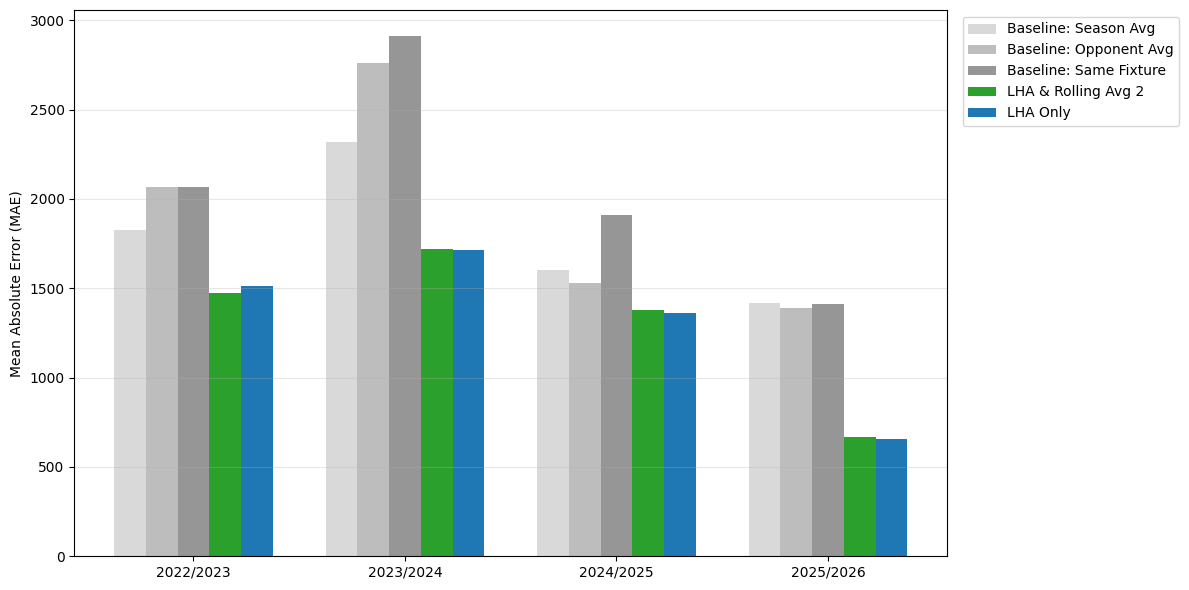

In [73]:
compare_feature_sets(
    df=df, 
    features_1=features_basic, 
    features_2=features_custom, 
    name_1=current_model_name, 
    name_2=new_model_name
)